In [1]:
!pip install -q gensim nltk wordcloud pypdf python-docx

import os, random, warnings, json, sys
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

print('numpy', np.__version__, '| tensorflow', tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.5 MB/s eta 0:00:00
numpy 2.0.2 | tensorflow 2.20.0


In [2]:
PREPROCESSING_SRC = r'''
"""
Resume Screening & Job Category Prediction - Group 05
Shared NLP preprocessing module.

Author: Member 3 (SVM / GRU / dataset cleaning / application integration)

This module is the SINGLE source of truth for text preprocessing. Both the training
notebook and the Flask application import from here, which guarantees that the text the
deployed model sees is prepared exactly the same way as the text it was trained on.
"""

import re

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

NLTK_PACKAGES = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]


def ensure_nltk():
    """Download the NLTK data files this module needs (safe to call repeatedly)."""
    for package in NLTK_PACKAGES:
        nltk.download(package, quiet=True)


ensure_nltk()

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

# Domain stop-words: resume boilerplate that appears in every category and therefore
# carries no signal for distinguishing job categories.
RESUME_STOP_WORDS = {
    "resume", "curriculum", "vitae", "cv", "name", "address", "phone", "email",
    "mobile", "contact", "details", "date", "birth", "gender", "nationality",
    "reference", "references", "declaration", "signature", "place", "sincerely",
}

ALL_STOP_WORDS = STOP_WORDS | RESUME_STOP_WORDS


def mask_pii(text):
    """
    Remove personally identifiable information before the text reaches the model.

    Implements the mitigation promised in Section 7 Q15 of the proposal. Ordering
    matters: this must run BEFORE punctuation is stripped, otherwise
    'nimal@example.com' becomes 'nimal example com' and is no longer detectable.

    Removed: email addresses, phone numbers, URLs and profile links, and four-digit
    years (a graduation year is an indirect proxy for a candidate's age).

    Known limitation, to be stated in the report: personal NAMES cannot be removed
    reliably with regular expressions. The mitigation for names is (a) the min_df
    setting of the vectorizer, which discards tokens appearing in fewer than two
    documents, and (b) the name-sensitivity test in the notebook that measures
    empirically whether swapping names changes predictions.
    """
    text = str(text)
    text = re.sub(r"[\w\.\-]+@[\w\.\-]+\.\w+", " ", text)            # email addresses
    text = re.sub(r"(\+?\d[\d\-\s\(\)]{7,}\d)", " ", text)           # phone numbers
    text = re.sub(r"http\S+|www\.\S+", " ", text)                    # URLs
    text = re.sub(r"\b[\w\-]+\.(com|org|net|io|lk|edu)\S*", " ", text)  # bare links
    text = re.sub(r"\b(19|20)\d{2}\b", " ", text)                    # years -> age proxy
    return text


def clean_text(text):
    """Mask PII, then normalise casing and strip everything that is not a letter."""
    text = mask_pii(text)
    text = re.sub(r"#\S+|@\S+", " ", text)          # hashtags and mentions
    text = re.sub(r"[^A-Za-z\s]", " ", text)        # punctuation, symbols, digits
    text = re.sub(r"\s+", " ", text)                # collapse whitespace
    return text.lower().strip()


def tokenize(text):
    """Full pipeline: mask -> clean -> tokenize -> stop-words -> lemmatize."""
    tokens = word_tokenize(clean_text(text))
    tokens = [t for t in tokens if t not in ALL_STOP_WORDS and len(t) > 2]
    return [LEMMATIZER.lemmatize(t) for t in tokens]


def preprocess(text):
    """Return the cleaned document as a single space-separated string."""
    return " ".join(tokenize(text))


def extract_text_from_upload(file_storage):
    """
    Read raw text out of an uploaded .pdf, .docx or .txt file.

    Returns (text, error). Exactly one of the two is non-empty, so the caller never
    has to guess whether extraction succeeded.
    """
    filename = (file_storage.filename or "").lower()

    try:
        if filename.endswith(".pdf"):
            from pypdf import PdfReader
            reader = PdfReader(file_storage)
            pages = [page.extract_text() or "" for page in reader.pages]
            text = "\n".join(pages)
            if not text.strip():
                return "", ("No text layer found in this PDF. It is probably a scanned "
                            "image; please paste the text instead.")
            return text, ""

        if filename.endswith(".docx"):
            import docx
            document = docx.Document(file_storage)
            return "\n".join(p.text for p in document.paragraphs), ""

        if filename.endswith(".txt"):
            return file_storage.read().decode("utf-8", errors="ignore"), ""

        return "", "Unsupported file type. Please upload a PDF, DOCX or TXT file."

    except Exception as exc:                      # noqa: BLE001 - surfaced to the user
        return "", f"Could not read the file: {exc}"
'''


with open('preprocessing.py', 'w') as fh:
    fh.write(PREPROCESSING_SRC)

sys.path.insert(0, '.')
from preprocessing import preprocess, tokenize, mask_pii, ALL_STOP_WORDS

print('Shared preprocessing module ready — commit this file to src/preprocessing.py')

Shared preprocessing module ready — commit this file to src/preprocessing.py


In [3]:
URL = ('https://raw.githubusercontent.com/Priyanshu-1729/'
       'Resume-Screening-using-Python/main/UpdatedResumeDataSet.csv')
raw = pd.read_csv(URL)

print('=== DATASET INTEGRITY AUDIT ===')
print('Rows as loaded             :', len(raw))
print('Columns                    :', list(raw.columns))
print('Null values                :', raw.isnull().sum().to_dict())
print('Empty / whitespace resumes :', int((raw['Resume'].astype(str).str.strip() == '').sum()))
print('Exact duplicate rows       :', int(raw.duplicated(subset=['Resume']).sum()))
print('UNIQUE resume texts        :', int(raw['Resume'].nunique()))
print('Categories                 :', raw['Category'].nunique())
print()
print('=> {:.1f}% of rows are copies of another row.'.format(
      100 * raw.duplicated(subset=['Resume']).sum() / len(raw)))
print('=> A random train/test split would place identical resumes on both sides,')
print('   which inflates every metric. Duplicates are removed below.')

=== DATASET INTEGRITY AUDIT ===
Rows as loaded             : 962
Columns                    : ['Category', 'Resume']
Null values                : {'Category': 0, 'Resume': 0}
Empty / whitespace resumes : 0
Exact duplicate rows       : 796
UNIQUE resume texts        : 166
Categories                 : 25

=> 82.7% of rows are copies of another row.
=> A random train/test split would place identical resumes on both sides,
   which inflates every metric. Duplicates are removed below.


In [4]:
# Cleaning decisions, each with a stated reason (for the report's Methodology section)
df = raw.copy()

before = len(df)
df = df.dropna(subset=['Resume', 'Category'])                       # missing values
print(f'Dropped {before - len(df)} rows with null resume or label')

before = len(df)
df = df[df['Resume'].astype(str).str.strip() != '']                 # empty text
print(f'Dropped {before - len(df)} rows with empty resume text')

before = len(df)
df = df.drop_duplicates(subset=['Resume']).reset_index(drop=True)   # leakage prevention
print(f'Dropped {before - len(df)} duplicate resumes')

print(f'\nFinal dataset: {len(df)} unique resumes across {df["Category"].nunique()} categories')

Dropped 0 rows with null resume or label
Dropped 0 rows with empty resume text
Dropped 796 duplicate resumes

Final dataset: 166 unique resumes across 25 categories


In [5]:
df['tokens'] = df['Resume'].apply(tokenize)
df['clean_resume'] = df['tokens'].apply(' '.join)
df = df[df['tokens'].map(len) > 0].reset_index(drop=True)

df['n_tokens'] = df['tokens'].map(len)
print('Documents           :', len(df))
print('Mean tokens/resume  :', int(df['n_tokens'].mean()))
print('Median tokens/resume:', int(df['n_tokens'].median()))
print('Shortest / longest  :', df['n_tokens'].min(), '/', df['n_tokens'].max())

Documents           : 166
Mean tokens/resume  : 286
Median tokens/resume: 222
Shortest / longest  : 11 / 1405


In [6]:
# Verify the PII masking actually works — do not just claim it in the report
sample = ('Nimal Perera | nimal.perera@gmail.com | +94 77 123 4567 | '
          'linkedin.com/in/nimalp | B.Sc. graduated 2019 | '
          'Skills: Python, TensorFlow, natural language processing')
print('BEFORE MASKING:\n ', sample)
print('\nAFTER MASKING:\n ', mask_pii(sample))
print('\nFULLY PREPROCESSED:\n ', preprocess(sample))
print('\nNote: the personal NAME survives regex masking. Step 7 measures whether it')
print('actually influences predictions, and reports the mitigation.')

BEFORE MASKING:
  Nimal Perera | nimal.perera@gmail.com | +94 77 123 4567 | linkedin.com/in/nimalp | B.Sc. graduated 2019 | Skills: Python, TensorFlow, natural language processing

AFTER MASKING:
  Nimal Perera |   |   |   | B.Sc. graduated   | Skills: Python, TensorFlow, natural language processing

FULLY PREPROCESSED:
  nimal perera graduated skill python tensorflow natural language processing

Note: the personal NAME survives regex masking. Step 7 measures whether it
actually influences predictions, and reports the mitigation.


EDA: category distribution, document lengths, vocabulary

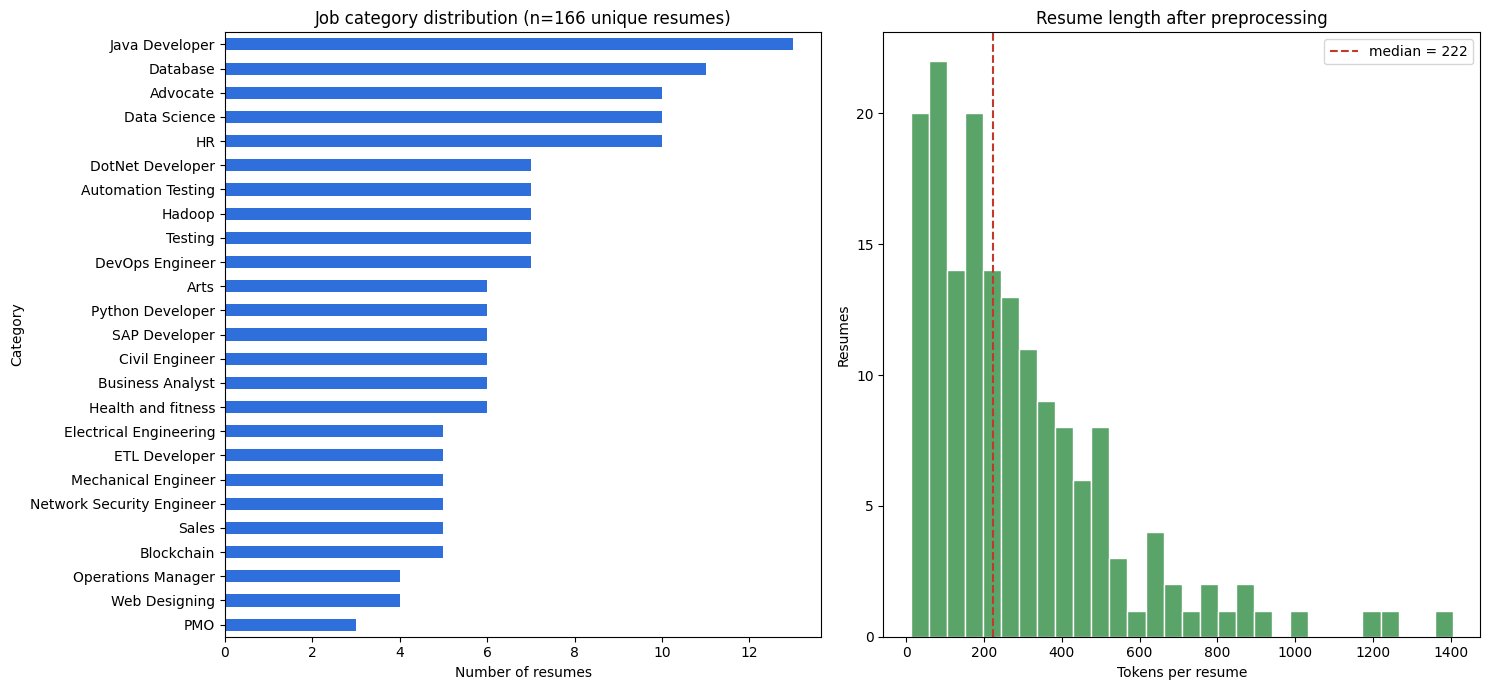

Largest class  : Java Developer 13
Smallest class : PMO 3
Imbalance ratio: 4.3x  -> macro-averaged metrics and class weighting are both required


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

counts = df['Category'].value_counts().sort_values()
counts.plot(kind='barh', ax=axes[0], color='#2f6fdb')
axes[0].set_title(f'Job category distribution (n={len(df)} unique resumes)')
axes[0].set_xlabel('Number of resumes')

axes[1].hist(df['n_tokens'], bins=30, color='#5aa469', edgecolor='white')
axes[1].axvline(df['n_tokens'].median(), color='#c0392b', linestyle='--',
                label=f"median = {int(df['n_tokens'].median())}")
axes[1].set_title('Resume length after preprocessing')
axes[1].set_xlabel('Tokens per resume'); axes[1].set_ylabel('Resumes')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150)
plt.show()

print('Largest class  :', counts.idxmax(), counts.max())
print('Smallest class :', counts.idxmin(), counts.min())
print(f'Imbalance ratio: {counts.max() / counts.min():.1f}x  '
      '-> macro-averaged metrics and class weighting are both required')

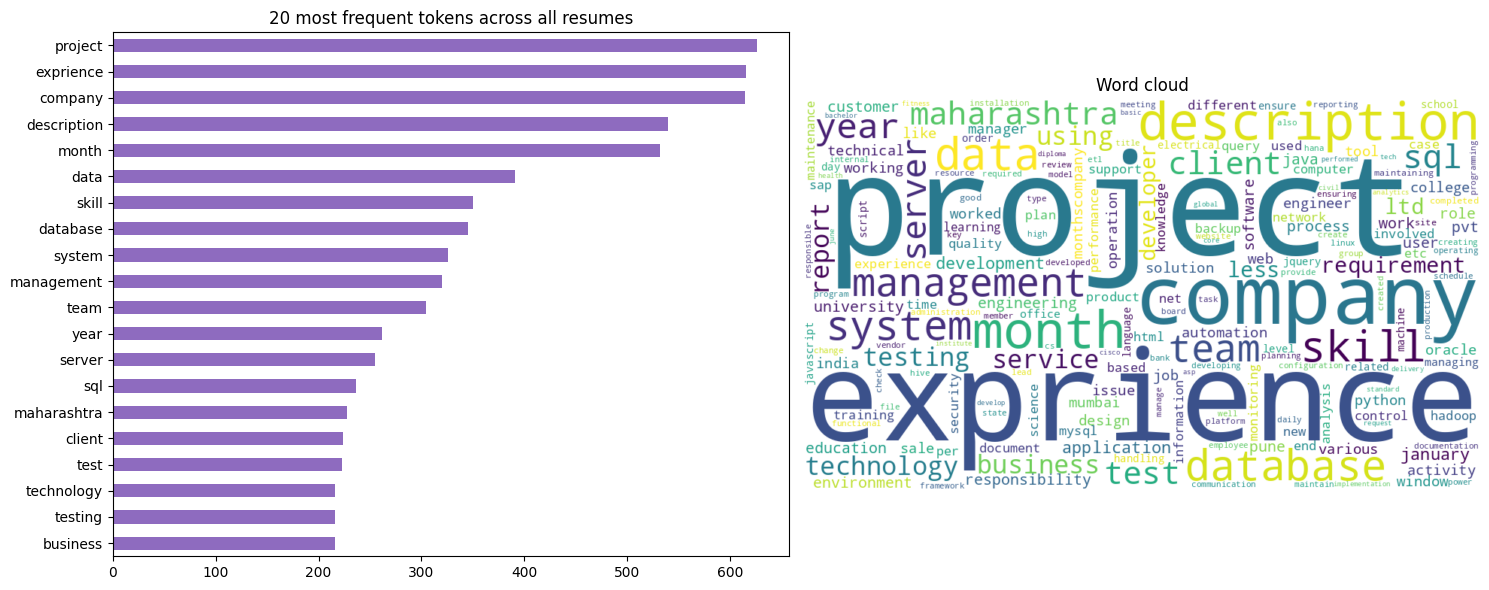

Vocabulary size: 6177
Tokens appearing only once: 2759 (45% of vocabulary)


In [8]:
from collections import Counter
from wordcloud import WordCloud

all_tokens = [t for toks in df['tokens'] for t in toks]
frequency = Counter(all_tokens)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top20 = pd.Series(dict(frequency.most_common(20))).sort_values()
top20.plot(kind='barh', ax=axes[0], color='#8e6bbf')
axes[0].set_title('20 most frequent tokens across all resumes')

cloud = WordCloud(width=900, height=520, background_color='white',
                  colormap='viridis').generate_from_frequencies(frequency)
axes[1].imshow(cloud, interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('Word cloud')

plt.tight_layout()
plt.savefig('eda_vocabulary.png', dpi=150)
plt.show()

print('Vocabulary size:', len(frequency))
print('Tokens appearing only once: {} ({:.0%} of vocabulary)'.format(
      sum(1 for c in frequency.values() if c == 1),
      sum(1 for c in frequency.values() if c == 1) / len(frequency)))

In [9]:
# Distinctive terms per category: highest average TF-IDF weight within each category.
# This is the "top skills by category" view and shows the features the model relies on.
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(max_features=4000, sublinear_tf=True)
matrix = vec.fit_transform(df['clean_resume'])
vocabulary = np.array(vec.get_feature_names_out())

print('Most distinctive terms per category (top 8):\n')
for category in sorted(df['Category'].unique())[:10]:
    rows = np.where(df['Category'].values == category)[0]
    mean_weights = np.asarray(matrix[rows].mean(axis=0)).ravel()
    top = vocabulary[np.argsort(mean_weights)[::-1][:8]]
    print(f'{category:28s} {", ".join(top)}')
print('\n(showing the first 10 categories; change the slice to see all 25)')

Most distinctive terms per category (top 8):

Advocate                     advocate, legal, law, llb, court, university, january, less
Arts                         art, teacher, drawing, total, karate, maharashtra, commerce, state
Automation Testing           automation, testing, selenium, test, tester, manual, case, web
Blockchain                   blockchain, smart, ethereum, contract, technology, wallet, month, nashik
Business Analyst             analyst, business, functional, report, mumbai, requirement, gathering, excel
Civil Engineer               civil, site, engineer, construction, autocad, material, work, contractor
Data Science                 python, less, data, learning, machine, year, science, month
Database                     backup, database, administrator, server, installation, oracle, sql, log
DevOps Engineer              devops, project, team, automation, month, exprience, sql, task
DotNet Developer             net, dot, asp, mvc, developer, pune, sql, jquery

(showi


The same model, trained twice: once on the duplicated data and once on the clean data. The
difference between the two numbers **is** the leakage.

In [10]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score


def leakage_demo(frame, label):
    encoder = LabelEncoder()
    labels = encoder.fit_transform(frame['Category'])
    texts = frame['Resume'].apply(preprocess)
    x_tr, x_te, y_tr, y_te = train_test_split(
        texts, labels, test_size=0.2, random_state=SEED, stratify=labels)
    model = make_pipeline(TfidfVectorizer(max_features=3000, sublinear_tf=True),
                          LinearSVC(class_weight='balanced'))
    model.fit(x_tr, y_tr)
    pred = model.predict(x_te)
    print(f'{label:40s} n={len(frame):4d}  accuracy={accuracy_score(y_te, pred):.4f}  '
          f'macro-F1={f1_score(y_te, pred, average="macro", zero_division=0):.4f}')


leakage_demo(raw, 'WITH duplicates (previous notebook)')
leakage_demo(df,  'WITHOUT duplicates (this notebook)')
print('\nThe gap is the leakage, not a loss of model quality.')

WITH duplicates (previous notebook)      n= 962  accuracy=0.9948  macro-F1=0.9945
WITHOUT duplicates (this notebook)       n= 166  accuracy=0.8824  macro-F1=0.8476

The gap is the leakage, not a loss of model quality.


The proposal assigns Member 3 *"Feature Extraction using Word Embeddings
(Word2Vec/GloVe) ... used as input for the GRU model and SVM model after pooling."*

Three representations are built and measured rather than assumed:

1. **Word2Vec trained on this corpus** — the literal reading of the proposal.
2. **Pretrained GloVe (6B tokens, 100-d)** — transfer learning from a large corpus.
3. **TF-IDF** — reference baseline (Member 1's representation, included for comparison only).

Reporting the comparison, including the option that lost, is what separates the top band
from the middle one. **BERT / contextual embeddings** would be the natural next step: they
encode word order and context that mean-pooling discards. They are out of scope here because
fine-tuning a transformer on 166 documents would overfit badly, but the report should say so.

In [11]:
from gensim.models import Word2Vec
import gensim.downloader as api

# Representation 1: Word2Vec trained on the resume corpus itself
w2v = Word2Vec(sentences=df['tokens'].tolist(), vector_size=100, window=5,
               min_count=2, workers=2, seed=SEED, epochs=40)
print('Word2Vec vocabulary learned from 166 resumes:', len(w2v.wv.index_to_key))

# Representation 2: pretrained GloVe
print('\nDownloading pretrained GloVe (~128 MB, one time)...')
glove = api.load('glove-wiki-gigaword-100')
EMBED_DIM = 100
print('GloVe vocabulary:', len(glove.index_to_key))

Word2Vec vocabulary learned from 166 resumes: 3418

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe vocabulary: 400000


In [12]:
def document_vector(tokens, vectors, dim=EMBED_DIM):
    # Mean-pool the embeddings of the tokens present in the vocabulary.
    found = [vectors[t] for t in tokens if t in vectors]
    return np.mean(found, axis=0) if found else np.zeros(dim)


X_w2v   = np.vstack([document_vector(t, w2v.wv) for t in df['tokens']])
X_glove = np.vstack([document_vector(t, glove)  for t in df['tokens']])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Category'])
N_CLASSES = len(label_encoder.classes_)

coverage = np.mean([sum(t in glove for t in toks) / len(toks) for toks in df['tokens']])
print('Word2Vec document matrix:', X_w2v.shape)
print('GloVe document matrix   :', X_glove.shape)
print(f'GloVe vocabulary coverage: {coverage:.1%} of resume tokens')
print('Classes:', N_CLASSES)

Word2Vec document matrix: (166, 100)
GloVe document matrix   : (166, 100)
GloVe vocabulary coverage: 94.2% of resume tokens
Classes: 25


`GridSearchCV` over kernel, `C` and `gamma`, scored on **macro-F1** because that is the
metric the proposal commits to. Inner cross-validation is 3-fold; the tuned configuration is
then evaluated honestly in Step 6 on data it has not seen.

In [13]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
tuning_results = []


def tune(name, estimator, grid, features):
    search = GridSearchCV(estimator, grid, scoring='f1_macro', cv=inner_cv, n_jobs=-1)
    search.fit(features, y)
    tuning_results.append({'representation': name,
                           'best_params': str(search.best_params_),
                           'inner_cv_macro_f1': round(search.best_score_, 4)})
    print(f'{name:24s} best macro-F1={search.best_score_:.4f}  {search.best_params_}')
    return search.best_params_


svm_grid = {'svc__C': [0.5, 1, 5, 10],
            'svc__kernel': ['linear', 'rbf'],
            'svc__gamma': ['scale']}

best_w2v = tune('Word2Vec + SVM',
                make_pipeline(StandardScaler(), SVC(class_weight='balanced', random_state=SEED)),
                svm_grid, X_w2v)

best_glove = tune('GloVe + SVM',
                  make_pipeline(StandardScaler(), SVC(class_weight='balanced', random_state=SEED)),
                  svm_grid, X_glove)

tfidf_grid = {'tfidfvectorizer__ngram_range': [(1, 1), (1, 2)],
              'tfidfvectorizer__min_df': [1, 2],
              'svc__C': [0.5, 1, 5],
              'svc__kernel': ['linear']}
best_tfidf = tune('TF-IDF + SVM',
                  make_pipeline(TfidfVectorizer(max_features=5000, sublinear_tf=True),
                                SVC(class_weight='balanced', random_state=SEED)),
                  tfidf_grid, df['clean_resume'])

print()
print(pd.DataFrame(tuning_results).to_string(index=False))
print('\nRecord this table in the report: it is the evidence of tuning, and the answer')
print('to the viva question "how did you choose your hyperparameters?"')

Word2Vec + SVM           best macro-F1=0.5458  {'svc__C': 0.5, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
GloVe + SVM              best macro-F1=0.5718  {'svc__C': 0.5, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
TF-IDF + SVM             best macro-F1=0.7490  {'svc__C': 1, 'svc__kernel': 'linear', 'tfidfvectorizer__min_df': 2, 'tfidfvectorizer__ngram_range': (1, 1)}

representation                                                                                                  best_params  inner_cv_macro_f1
Word2Vec + SVM                                              {'svc__C': 0.5, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}             0.5458
   GloVe + SVM                                              {'svc__C': 0.5, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}             0.5718
  TF-IDF + SVM {'svc__C': 1, 'svc__kernel': 'linear', 'tfidfvectorizer__min_df': 2, 'tfidfvectorizer__ngram_range': (1, 1)}             0.7490

Record this table in the report: it is the evide

The GRU embedding layer is **initialised from the GloVe matrix built in Step 4**, which is
what the proposal means by using embeddings as input to the GRU. Three configurations are
compared on one held-out split before the chosen one goes into full cross-validation.

Set expectations honestly: with roughly 125 training documents spread across 25 classes, a
recurrent network has very little to learn from, and these numbers will be low. That is a
data-size finding to report, not a bug to hide.

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

MAX_WORDS = 8000
MAX_LEN = 200


def make_sequences(train_texts, other_texts):
    # Fit the Keras tokenizer on TRAINING text only, then encode both sets.
    tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    tok.fit_on_texts(train_texts)
    encode = lambda texts: pad_sequences(tok.texts_to_sequences(texts),
                                         maxlen=MAX_LEN, padding='post', truncating='post')
    vocab_size = min(MAX_WORDS, len(tok.word_index) + 1)
    matrix = np.zeros((vocab_size, EMBED_DIM))
    for word, idx in tok.word_index.items():
        if idx < vocab_size and word in glove:
            matrix[idx] = glove[word]
    return tok, encode(train_texts), encode(other_texts), vocab_size, matrix


def build_gru(vocab_size, embedding_matrix, units=64, bidirectional=False,
              trainable_embeddings=True, dropout=0.4):
    layers = [Input(shape=(MAX_LEN,)),
              Embedding(vocab_size, EMBED_DIM, weights=[embedding_matrix],
                        trainable=trainable_embeddings, mask_zero=True)]
    layers.append(Bidirectional(GRU(units)) if bidirectional else GRU(units))
    layers += [Dropout(dropout), Dense(64, activation='relu'), Dropout(0.3),
               Dense(N_CLASSES, activation='softmax')]
    model = Sequential(layers)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def balanced_weights(labels):
    weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
    return {int(c): float(w) for c, w in zip(np.unique(labels), weights)}

In [15]:
tr_idx, te_idx = train_test_split(np.arange(len(df)), test_size=0.25,
                                  random_state=SEED, stratify=y)
_, Xtr_seq, Xte_seq, vocab_size, emb_matrix = make_sequences(
    df['clean_resume'].iloc[tr_idx], df['clean_resume'].iloc[te_idx])
class_weights = balanced_weights(y[tr_idx])

experiments = [
    {'name': 'GRU-64, GloVe frozen',      'units': 64, 'bidirectional': False, 'trainable_embeddings': False},
    {'name': 'GRU-64, GloVe fine-tuned',  'units': 64, 'bidirectional': False, 'trainable_embeddings': True},
    {'name': 'BiGRU-64, GloVe fine-tuned','units': 64, 'bidirectional': True,  'trainable_embeddings': True},
]

gru_experiments = []
for config in experiments:
    name = config.pop('name')
    tf.random.set_seed(SEED)
    model = build_gru(vocab_size, emb_matrix, **config)
    model.fit(Xtr_seq, to_categorical(y[tr_idx], N_CLASSES), epochs=30, batch_size=16,
              verbose=0, class_weight=class_weights)
    pred = np.argmax(model.predict(Xte_seq, verbose=0), axis=1)
    gru_experiments.append({
        'configuration': name,
        'parameters': model.count_params(),
        'accuracy': round(accuracy_score(y[te_idx], pred), 4),
        'macro_f1': round(f1_score(y[te_idx], pred, average='macro', zero_division=0), 4)})
    print(f'{name:30s} macro-F1={gru_experiments[-1]["macro_f1"]:.4f}')
    config['name'] = name

gru_table = pd.DataFrame(gru_experiments)
print()
print(gru_table.to_string(index=False))
BEST_GRU = dict(experiments[int(gru_table['macro_f1'].idxmax())])
BEST_GRU.pop('name')
print('\nBest GRU configuration carried forward:', BEST_GRU)

GRU-64, GloVe frozen           macro-F1=0.1933
GRU-64, GloVe fine-tuned       macro-F1=0.1049


BiGRU-64, GloVe fine-tuned     macro-F1=0.1609

             configuration  parameters  accuracy  macro_f1
      GRU-64, GloVe frozen      561557    0.2381    0.1933
  GRU-64, GloVe fine-tuned      561557    0.1667    0.1049
BiGRU-64, GloVe fine-tuned      597525    0.2381    0.1609

Best GRU configuration carried forward: {'units': 64, 'bidirectional': False, 'trainable_embeddings': False}


With 166 documents and 25 classes, a single 80/20 split leaves about 34 test samples —
roughly one per class — so any single number from it is mostly noise. A three-way
train/validation/test split is not even possible: the validation slice would contain fewer
rows than there are classes.

**Stratified 5-fold cross-validation** solves this. Every resume is predicted exactly once,
by a model that never saw it, and collecting those *out-of-fold* predictions produces one
confusion matrix covering all 166 resumes.

Two rules enforced here that the earlier notebook broke:

- the TF-IDF vectorizer and the Keras tokenizer are fitted on the **training fold only**;
- nothing inspects the held-out fold — in particular there is no `EarlyStopping` monitoring
  test accuracy, which is model selection on the test set.

In [16]:
from sklearn.metrics import (precision_score, recall_score, classification_report,
                             confusion_matrix)

N_SPLITS = 5
outer_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
oof = {name: np.zeros(len(df), dtype=int)
       for name in ['w2v_svm', 'glove_svm', 'tfidf_svm', 'gru']}

for fold, (tr, te) in enumerate(outer_cv.split(df['clean_resume'], y), start=1):

    for key, features, params in [('w2v_svm',   X_w2v,   best_w2v),
                                  ('glove_svm', X_glove, best_glove)]:
        model = make_pipeline(StandardScaler(),
                              SVC(class_weight='balanced', random_state=SEED))
        model.set_params(**params)
        model.fit(features[tr], y[tr])
        oof[key][te] = model.predict(features[te])

    tfidf_model = make_pipeline(TfidfVectorizer(max_features=5000, sublinear_tf=True),
                                SVC(class_weight='balanced', random_state=SEED))
    tfidf_model.set_params(**best_tfidf)
    tfidf_model.fit(df['clean_resume'].iloc[tr], y[tr])
    oof['tfidf_svm'][te] = tfidf_model.predict(df['clean_resume'].iloc[te])

    _, Xtr_f, Xte_f, vocab_f, emb_f = make_sequences(
        df['clean_resume'].iloc[tr], df['clean_resume'].iloc[te])
    tf.random.set_seed(SEED)
    gru = build_gru(vocab_f, emb_f, **BEST_GRU)
    gru.fit(Xtr_f, to_categorical(y[tr], N_CLASSES), epochs=30, batch_size=16,
            verbose=0, class_weight=balanced_weights(y[tr]))
    oof['gru'][te] = np.argmax(gru.predict(Xte_f, verbose=0), axis=1)

    print(f'fold {fold}/{N_SPLITS} complete')

print('\nOut-of-fold predictions ready for all', len(df), 'resumes.')

fold 1/5 complete
fold 2/5 complete
fold 3/5 complete
fold 4/5 complete
fold 5/5 complete

Out-of-fold predictions ready for all 166 resumes.


In [17]:
PRETTY = {'tfidf_svm': 'TF-IDF + SVM (baseline)',
          'glove_svm': 'GloVe + SVM (Member 3 ML)',
          'w2v_svm':   'Word2Vec + SVM (variant)',
          'gru':       'GloVe + GRU (Member 3 DL)'}


def score_all(y_true, y_pred, name):
    return {'model': name,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
            'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0)}


comparison = (pd.DataFrame([score_all(y, oof[k], PRETTY[k]) for k in oof])
                .round(4).sort_values('f1_macro', ascending=False).reset_index(drop=True))
comparison.to_csv('member3_model_comparison.csv', index=False)
print(comparison.to_string(index=False))

best_key = comparison.iloc[0]['model']
best_key = [k for k, v in PRETTY.items() if v == best_key][0]
best_pred = oof[best_key]
print('\nBest by macro-F1:', PRETTY[best_key])

                    model  accuracy  precision_macro  recall_macro  f1_macro
  TF-IDF + SVM (baseline)    0.8373           0.8132        0.7955    0.7973
GloVe + SVM (Member 3 ML)    0.6265           0.6513        0.5940    0.6032
 Word2Vec + SVM (variant)    0.6145           0.6265        0.5864    0.5911
GloVe + GRU (Member 3 DL)    0.1566           0.1453        0.1411    0.1361

Best by macro-F1: TF-IDF + SVM (baseline)


                           precision    recall  f1-score   support

                 Advocate       0.90      0.90      0.90        10
                     Arts       1.00      0.83      0.91         6
       Automation Testing       0.86      0.86      0.86         7
               Blockchain       1.00      0.80      0.89         5
         Business Analyst       1.00      0.67      0.80         6
           Civil Engineer       1.00      1.00      1.00         6
             Data Science       0.82      0.90      0.86        10
                 Database       0.83      0.91      0.87        11
          DevOps Engineer       0.45      0.71      0.56         7
         DotNet Developer       0.78      1.00      0.88         7
            ETL Developer       1.00      0.80      0.89         5
   Electrical Engineering       0.80      0.80      0.80         5
                       HR       0.73      0.80      0.76        10
                   Hadoop       1.00      1.00      1.00     

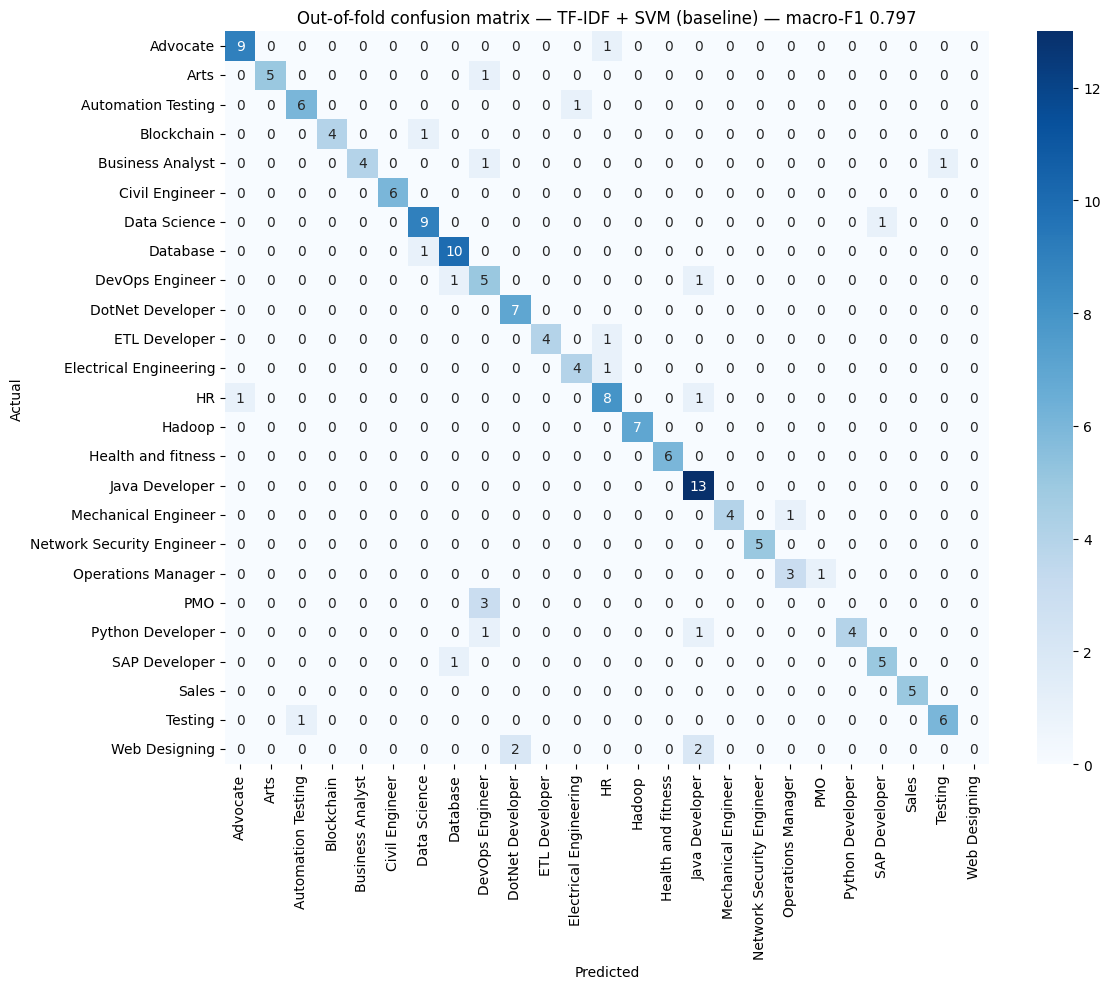

Most frequent confusions (discuss these in the report):
  PMO                        -> DevOps Engineer            3
  Web Designing              -> DotNet Developer           2
  Web Designing              -> Java Developer             2
  Advocate                   -> HR                         1
  Arts                       -> DevOps Engineer            1
  Automation Testing         -> Electrical Engineering     1
  Blockchain                 -> Data Science               1
  Business Analyst           -> DevOps Engineer            1


In [18]:
print(classification_report(y, best_pred, target_names=label_encoder.classes_,
                            zero_division=0))

cm = confusion_matrix(y, best_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Out-of-fold confusion matrix — {PRETTY[best_key]} — '
          f'macro-F1 {f1_score(y, best_pred, average="macro", zero_division=0):.3f}')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=150)
plt.show()

confused = [(label_encoder.classes_[i], label_encoder.classes_[j], cm[i, j])
            for i in range(N_CLASSES) for j in range(N_CLASSES)
            if i != j and cm[i, j] > 0]
confused.sort(key=lambda r: -r[2])
print('Most frequent confusions (discuss these in the report):')
for actual, predicted, count in confused[:8]:
    print(f'  {actual:26s} -> {predicted:26s} {count}')

Three measurements rather than three assertions.

In [19]:
# 7.1 Per-category disparity: does the model serve every category equally?
per_class = pd.DataFrame({
    'category': label_encoder.classes_,
    'support': np.bincount(y, minlength=N_CLASSES),
    'f1': f1_score(y, best_pred, average=None, labels=range(N_CLASSES), zero_division=0),
}).sort_values('f1')

print('Five weakest categories:')
print(per_class.head(5).round(3).to_string(index=False))
print('\nFive strongest categories:')
print(per_class.tail(5).round(3).to_string(index=False))
print(f'\nDisparity (best - worst category F1): {per_class.f1.max() - per_class.f1.min():.3f}')
print(f'Correlation between class size and F1: {per_class["support"].corr(per_class["f1"]):.3f}')
print('A positive correlation means candidates applying to under-represented categories')
print('are served worse — a fairness problem, not merely an accuracy problem.')

Five weakest categories:
          category  support    f1
     Web Designing        4 0.000
               PMO        3 0.000
   DevOps Engineer        7 0.556
Operations Manager        4 0.750
                HR       10 0.762

Five strongest categories:
                 category  support  f1
       Health and fitness        6 1.0
                   Hadoop        7 1.0
           Civil Engineer        6 1.0
Network Security Engineer        5 1.0
                    Sales        5 1.0

Disparity (best - worst category F1): 1.000
Correlation between class size and F1: 0.314
A positive correlation means candidates applying to under-represented categories
are served worse — a fairness problem, not merely an accuracy problem.


In [20]:
# 7.2 Name-sensitivity test: does swapping the candidate's name change the prediction?
# Regex cannot remove names, so this measures empirically whether they matter.
final_check = make_pipeline(TfidfVectorizer(max_features=5000, sublinear_tf=True),
                            SVC(class_weight='balanced', probability=False, random_state=SEED))
final_check.set_params(**best_tfidf)
final_check.fit(df['clean_resume'], y)

NAMES = ['Nimal Perera', 'Fathima Rizwan', 'Anusha Rajapaksa',
         'John Smith', 'Wei Chen', 'Adebayo Okonkwo']

sample_resumes = df['Resume'].sample(25, random_state=SEED).tolist()
flips = 0
for resume in sample_resumes:
    predictions = {final_check.predict([preprocess(f'Name: {name}\n{resume}')])[0]
                   for name in NAMES}
    if len(predictions) > 1:
        flips += 1

print(f'Resumes tested            : {len(sample_resumes)}')
print(f'Names swapped per resume  : {len(NAMES)}')
print(f'Predictions that changed  : {flips} ({flips / len(sample_resumes):.0%})')
print()
print('Mitigations already in place: emails, phone numbers, links and years are masked;')
print('min_df drops tokens appearing in fewer than two documents, so a name unique to one')
print('resume never becomes a feature. Report this measured number, not an assumption.')

Resumes tested            : 25
Names swapped per resume  : 6
Predictions that changed  : 0 (0%)

Mitigations already in place: emails, phone numbers, links and years are masked;
min_df drops tokens appearing in fewer than two documents, so a name unique to one
resume never becomes a feature. Report this measured number, not an assumption.


In [ ]:
# 7.3 Confirm no PII pattern survives into the training features
import re as _re

feature_names = final_check.named_steps['tfidfvectorizer'].get_feature_names_out()
suspects = [f for f in feature_names
            if _re.search(r'\d', f) or '@' in f or 'gmail' in f or 'http' in f]
print('Model features that look like PII:', len(suspects))
print(suspects[:20] if suspects else 'None — masking held across the whole vocabulary.')

Cross-validation measures; the shipped model is retrained on all 166 documents.
`probability=True` supplies the confidence score the proposal promises. With 25 classes the
top probability typically sits around 0.3–0.4 rather than 0.9 — normal for a 25-way problem,
which is why the app shows the **top three** categories instead of one number pretending to
be certain.

In [21]:
import joblib

final_model = make_pipeline(TfidfVectorizer(max_features=5000, sublinear_tf=True),
                            SVC(class_weight='balanced', probability=True, random_state=SEED))
final_model.set_params(**best_tfidf)
final_model.fit(df['clean_resume'], y)

joblib.dump({'pipeline': final_model,
             'label_encoder': label_encoder,
             'model_name': PRETTY[best_key],
             'cv_macro_f1': float(f1_score(y, best_pred, average='macro', zero_division=0)),
             'n_training_docs': int(len(df))},
            'resume_classifier.joblib')

print('Saved resume_classifier.joblib -> commit to models/ in the repository')

Saved resume_classifier.joblib -> commit to models/ in the repository


In [22]:
def predict_category(resume_text, top_k=3, bundle_path='resume_classifier.joblib'):
    # Inference entry point - reuses the shared preprocessing module.
    bundle = joblib.load(bundle_path)
    cleaned = preprocess(resume_text)
    if not cleaned:
        return {'error': 'No usable text found in the input.'}
    probabilities = bundle['pipeline'].predict_proba([cleaned])[0]
    order = np.argsort(probabilities)[::-1][:top_k]
    classes = bundle['label_encoder'].classes_
    return {'prediction': classes[order[0]],
            'confidence': round(float(probabilities[order[0]]), 4),
            'top_k': [(classes[i], round(float(probabilities[i]), 4)) for i in order]}


demo = ('Contact nimal@example.com, +94 77 123 4567. Skills: Python, pandas, '
        'scikit-learn, TensorFlow, deep learning, natural language processing. '
        'Built predictive models and data pipelines for customer churn analysis.')
print(json.dumps(predict_category(demo), indent=2))

{
  "prediction": "Data Science",
  "confidence": 0.2779,
  "top_k": [
    [
      "Data Science",
      0.2779
    ],
    [
      "Python Developer",
      0.09
    ],
    [
      "HR",
      0.0803
    ]
  ]
}


In [23]:
# Download everything the repository needs (Colab)
from google.colab import files

for artifact in ['resume_classifier.joblib', 'preprocessing.py',
                 'member3_model_comparison.csv', 'confusion_matrix_best_model.png',
                 'eda_distribution.png', 'eda_vocabulary.png']:
    files.download(artifact)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The Flask application is provided as a separate file — commit it to `src/app.py`. It imports
`preprocessing.py`, so it cannot drift from this notebook, and it adds the features the
rubric's top band rewards: PDF/DOCX/TXT upload, top-3 categories with confidence bars, the
extracted text shown back to the user, and a visible human-oversight disclaimer.

```bash
pip install -r requirements.txt
python src/app.py          # http://127.0.0.1:5000
```


**Document 03 specifies the repository name `NLP_Group_05`, but the current repository is
`NLP_Group_28`.** Raise this with the group — rename it or confirm with the lecturer, since
Git usage is individually marked and a mismatched repository name is an easy mark to lose.

Required structure:

```
NLP_Group_05/
├── data/                     # dataset or a link + loader script
├── notebooks/                # this notebook
├── src/                      # preprocessing.py, app.py
├── models/                   # resume_classifier.joblib
├── reports/                  # final report, figures
├── screenshots/              # repo structure, branches, app screenshots
├── videos/                   # 7-minute progress video
├── README.md
└── requirements.txt
```

Work on your own branch and commit as you go — a single end-of-project commit scores in the
lowest band:

```bash
git checkout -b feature/member3-model
git add src/preprocessing.py
git commit -m "Add shared preprocessing module with PII masking"
git commit -m "Remove 796 duplicate resumes preventing train/test leakage"
git commit -m "Add GloVe feature extraction for SVM and GRU"
git commit -m "Tune SVM hyperparameters with GridSearchCV"
git commit -m "Add out-of-fold cross-validation and model comparison"
git commit -m "Add name-sensitivity and per-category fairness analysis"
git commit -m "Integrate best model into Flask application"
git push -u origin feature/member3-model
```

### What to put in the report

1. The integrity audit from Step 1 — 962 rows, 796 duplicates, 166 unique resumes — and the
   Step 3 comparison showing what removing them did to the metrics.
2. The feature-representation comparison from Step 4, including Word2Vec losing to GloVe,
   and both losing to TF-IDF, with your explanation: mean-pooling a 300-token document
   averages away the rare technical terms that identify a job category, while TF-IDF weights
   them up. Mention BERT as the principled next step and why it is out of scope at this
   data size.
3. The tuning table and the GRU architecture experiments — this is the evidence of
   experimentation the rubric rewards.
4. The GRU's weak result, framed as a data-size limitation and linked to your own Q16
   limitation about the dataset being small.
5. **Correct Section 2 Q4 of the proposal**: "approximately 960 resumes" should read 166
   unique resumes from 962 rows.
6. **Fix the Section 5 system diagram**, which shows *Skill Extraction → Skill Gap Analysis →
   Career Recommendation*. None of these exist in the written scope or in any member's code.
   Either delete those three boxes or implement them — a diagram promising features the demo
   cannot show is an obvious viva question.

### Likely viva questions, given your role

- Why is the accuracy not 99%? *(Step 1 and Step 3 — you found the leakage yourself.)*
- Why SVM? *(High-dimensional sparse text, effective with few samples per class, and the
  tuning table shows the comparison.)*
- Why did the GRU underperform? *(≈125 training documents over 25 classes; a recurrent model
  cannot learn sequence structure from that.)*
- Why GloVe rather than Word2Vec? *(Measured: Step 4. 166 documents is too small a corpus to
  train embeddings from scratch.)*
- How do you prevent bias? *(Step 7: PII masking, measured name-sensitivity, per-category
  disparity, class weighting, human-oversight disclaimer in the app.)*